<a href="https://colab.research.google.com/github/zoroubo/MDS-lab/blob/main/week_6%2C7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Generating Sample Data and Performing Simple Linear Regression

First, we'll create some synthetic data to work with. This data will have a linear relationship with some added random noise to simulate real-world data.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Independent variable
y = 4 + 3 * X + np.random.randn(100, 1) # Dependent variable with noise

# Create a DataFrame for easier handling
df = pd.DataFrame({'X': X.flatten(), 'y': y.flatten()})

# Add a constant to the independent variable for statsmodels (for the intercept)
X_const = sm.add_constant(X)

# Fit the simple linear regression model
model = sm.OLS(y, X_const)
results = model.fit()

print("--- Regression Results ---")
print(results.summary())

# Display the first few rows of the data
print("\n--- Sample Data (first 5 rows) ---")
display(df.head())

--- Regression Results ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     326.7
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           5.66e-33
Time:                        05:36:17   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2151    

,X,y
0,0.749080,6.334288
1,1.901429,9.405278
2,1.463988,8.483724
3,1.197317,5.604382
4,0.312037,4.716440


### 2. Residual Analysis and Plots

Residuals are the differences between the observed and predicted values. Analyzing them helps us assess the assumptions of linear regression (linearity, homoscedasticity, normality of residuals, and independence).

We'll create a plot of residuals versus fitted values to check for homoscedasticity and linearity, and a histogram of residuals to check for normality.

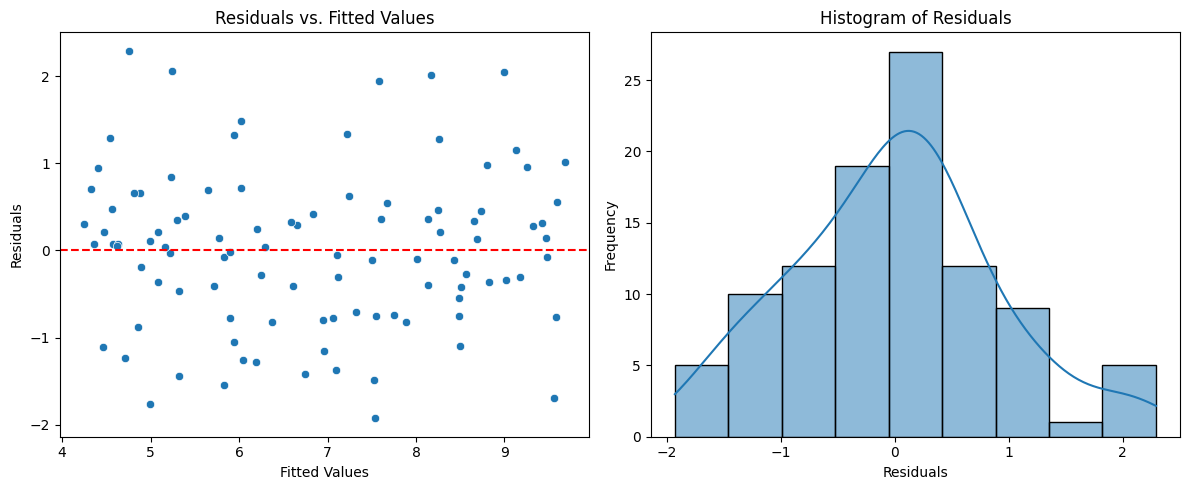

In [2]:
# Get the residuals from the model results
residuals = results.resid

# Get the fitted values (predicted y values)
fitted_values = results.fittedvalues

# Create a DataFrame for residuals and fitted values for easier plotting
residuals_df = pd.DataFrame({'Fitted Values': fitted_values, 'Residuals': residuals})

plt.figure(figsize=(12, 5))

# Residuals vs. Fitted Values Plot
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x='Fitted Values', y='Residuals', data=residuals_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

# Histogram of Residuals
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3. Normal Probability Plot of Residuals

A Q-Q plot (Quantile-Quantile plot) is used to check if the residuals follow a normal distribution. If the residuals are normally distributed, the points on the plot will roughly follow a straight line.

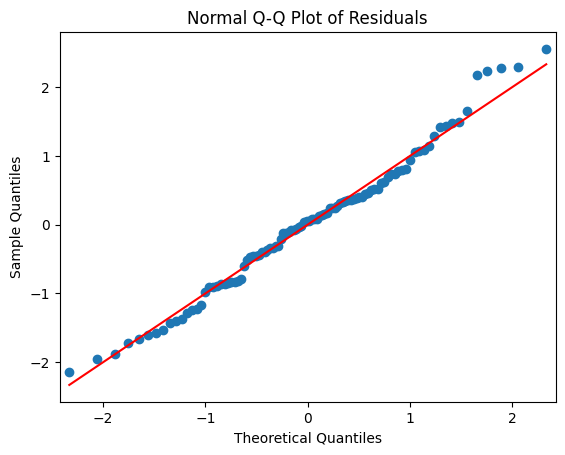

In [3]:
import statsmodels.graphics.gofplots as sm_plots

# Create a Q-Q plot of the residuals
fig = sm_plots.qqplot(residuals, line='s', fit=True)
plt.title('Normal Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

### 4. Empirical Model of Linear Regression Analysis

This plot visualizes the relationship between the independent variable (X) and the dependent variable (y), along with the fitted regression line. This helps to understand how well the model captures the linear trend in the data.

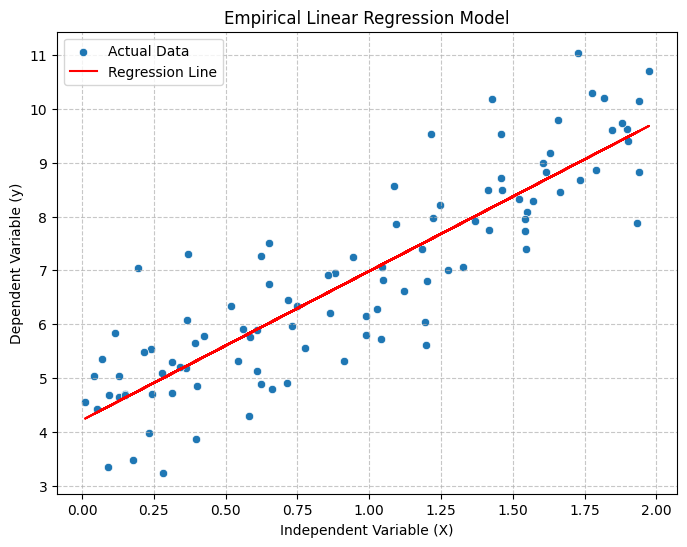

In [4]:
# Plotting the data and the regression line
plt.figure(figsize=(8, 6))
sns.scatterplot(x='X', y='y', data=df, label='Actual Data')
plt.plot(X, results.predict(X_const), color='red', label='Regression Line')
plt.title('Empirical Linear Regression Model')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()